# Train a KIND model on detuning data

In [1]:
# --! include root folder into PYTHONPATH

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/kalman'
model_dir = '../../models/kalman'

# --! import Python libraries and KIND framework files

import torch
import numpy as np
from matplotlib import pyplot as plt

import kind
import util_data
import util_nn
import example_kalman

In [2]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[0]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 3


In [3]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'kalman',
        '--data_nsample_baseline', '5000',
        '--data_nsample_nom', '144',
        '--data_nsample_exc', '144',
        '--obs_ndim', '1',
        '--act_ndim', '0',
        '--target_ndim', '1',
        '--data_train_size', '0.8',

        '--back_nsample', '96',
        '--fore_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '48',
        '--rez_nsample_exc', '12',
        '--embed_nom', '{"sin": 3, "cos": 3}',
        '--embed_exc', '{"sin": 5, "cos": 5}',
    ]
)

setpoint = torch.tensor([0.0])

In [4]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_kalman.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

## Train nominal model

In [5]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.146303, valid=0.141085, test=0.139788
	validation loss decreased (inf -> 0.141085), saving model ...
	epoch 2 losses: train=0.139451, valid=0.139273, test=0.138123
	validation loss decreased (0.141085 -> 0.139273), saving model ...
	epoch 3 losses: train=0.138794, valid=0.139117, test=0.137940
	validation loss decreased (0.139273 -> 0.139117), saving model ...
	epoch 4 losses: train=0.138644, valid=0.139060, test=0.137858
	validation loss decreased (0.139117 -> 0.139060), saving model ...
	epoch 5 losses: train=0.138607, valid=0.138995, test=0.137847
	validation loss decreased (0.139060 -> 0.138995), saving model ...
	epoch 6 losses: train=0.138560, valid=0.138965, test=0.137898
	validation loss decreased (0.138995 -> 0.138965), saving model ...
	epoch 7 losses: train=0.138581, valid=0.138968, test=0.137812
	early stopping counter: 1 out of 100
	epoch 8 losses: train=0.138542, valid=0.138968, test=0.137853
	early stopping counter: 

## Evaluate nominal model

In [6]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

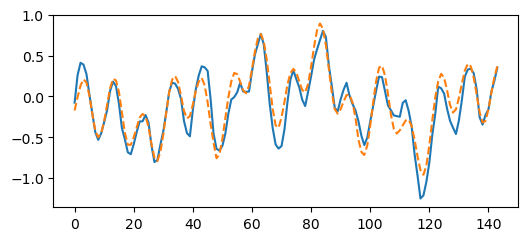

In [7]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')

        plt.show()

        break

## Train nominal uncertainty

In [8]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=7.065375, valid=6.005672, test=8.382872
	validation loss decreased (inf -> 6.005672), saving model ...
	epoch 2 losses: train=6.699714, valid=5.674407, test=7.669580
	validation loss decreased (6.005672 -> 5.674407), saving model ...
	epoch 3 losses: train=6.883460, valid=5.845822, test=8.000781
	early stopping counter: 1 out of 100
	epoch 4 losses: train=6.862460, valid=6.445051, test=10.052881
	early stopping counter: 2 out of 100
	epoch 5 losses: train=9.381479, valid=6.818614, test=8.997149
	early stopping counter: 3 out of 100
	epoch 6 losses: train=7.194454, valid=6.098184, test=8.159185
	early stopping counter: 4 out of 100
	epoch 7 losses: train=6.907486, valid=6.146323, test=8.024042
	early stopping counter: 5 out of 100
	epoch 8 losses: train=6.932289, valid=6.196443, test=8.009251
	early stopping counter: 6 out of 100
	epoch 9 losses: train=7.454904, valid=7.459508, test=9.176562
	early stopping counter: 7 out of 10

## Evaluate nominal uncertainty

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

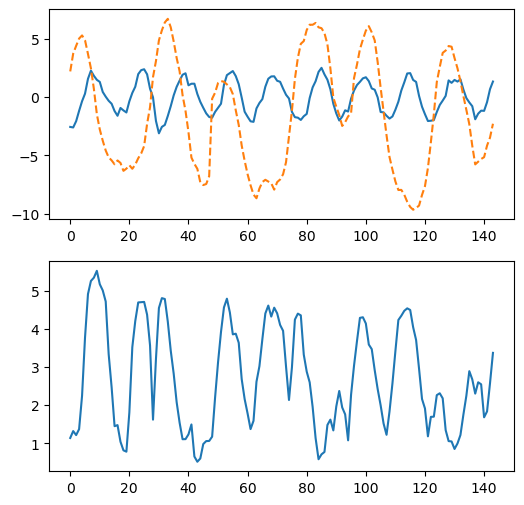

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :1])

        plt.show()

        break

## Train excursion model

In [11]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=1.941206, valid=1.637504, test=1.978430
	validation loss decreased (inf -> 1.637504), saving model ...
	epoch 2 losses: train=1.887314, valid=1.626539, test=1.965886
	validation loss decreased (1.637504 -> 1.626539), saving model ...
	epoch 3 losses: train=1.845994, valid=1.478884, test=1.787964
	validation loss decreased (1.626539 -> 1.478884), saving model ...
	epoch 4 losses: train=1.528403, valid=1.148322, test=1.372383
	validation loss decreased (1.478884 -> 1.148322), saving model ...
	epoch 5 losses: train=1.167875, valid=0.756381, test=0.912805
	validation loss decreased (1.148322 -> 0.756381), saving model ...
	epoch 6 losses: train=0.672664, valid=0.480698, test=0.562409
	validation loss decreased (0.756381 -> 0.480698), saving model ...
	epoch 7 losses: train=0.523274, valid=0.400878, test=0.471063
	validation loss decreased (0.480698 -> 0.400878), saving model ...
	epoch 8 losses: train=0.458831, valid=0.381813, test=0.

## Evaluate excursion model

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

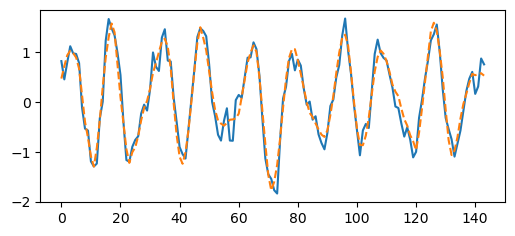

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

## Train excursion uncertainty

In [14]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.102488, valid=0.088087, test=0.089313
	validation loss decreased (inf -> 0.088087), saving model ...
	epoch 2 losses: train=0.087527, valid=0.086329, test=0.087346
	validation loss decreased (0.088087 -> 0.086329), saving model ...
	epoch 3 losses: train=0.086553, valid=0.085873, test=0.086876
	validation loss decreased (0.086329 -> 0.085873), saving model ...
	epoch 4 losses: train=0.086080, valid=0.085705, test=0.086702
	validation loss decreased (0.085873 -> 0.085705), saving model ...
	epoch 5 losses: train=0.085638, valid=0.085633, test=0.086615
	validation loss decreased (0.085705 -> 0.085633), saving model ...
	epoch 6 losses: train=0.086241, valid=0.085586, test=0.086579
	validation loss decreased (0.085633 -> 0.085586), saving model ...
	epoch 7 losses: train=0.085509, valid=0.085573, test=0.086558
	validation loss decreased (0.085586 -> 0.085573), saving model ...
	epoch 8 losses: train=0.085996, valid=0.085523, 

## Evaluate excursion uncertainty

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

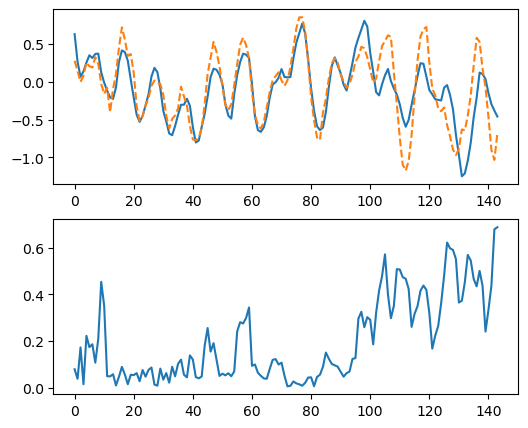

In [16]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

## Evaluate KIND blending

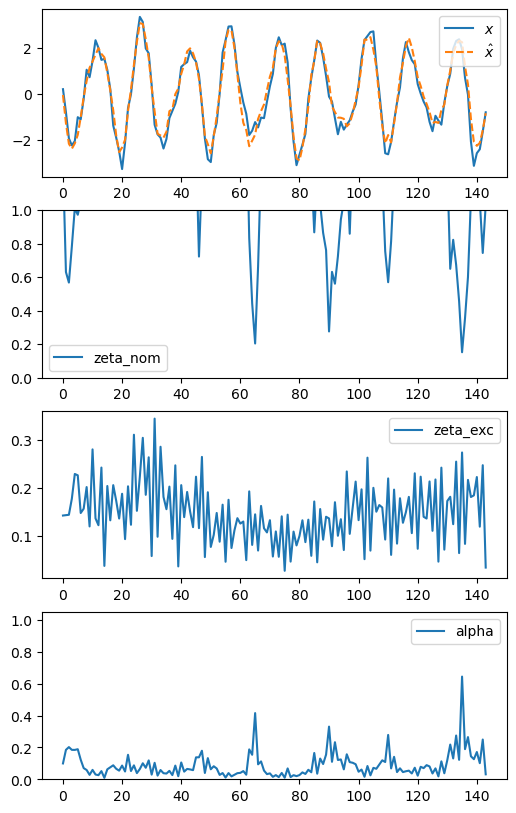

In [17]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='$x$')
        plt.plot(pre[0, :, :1], linestyle='dashed', label='$\\hat{x}$')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break